# **Analisis Sentimen Netizen terhadap Aplikasi JMO (Jaminan Sosial Mobile) dari Ulasan Google Play Store**

**1. Latar Belakang**<br>
Aplikasi JMO (Jaminan Sosial Mobile) merupakan salah satu inovasi digital dari BPJS Ketenagakerjaan untuk memudahkan peserta dalam mengakses layanan jaminan sosial tenaga kerja secara daring. Untuk mengetahui bagaimana persepsi masyarakat terhadap aplikasi ini, diperlukan pendekatan analitik yang mampu mengolah data dalam jumlah besar. Salah satunya adalah dengan melakukan analisis sentimen berdasarkan ulasan pengguna di Google Play Store, menggunakan metode machine learning.

**2 Tujuan**
- Mengkategorikan ulasan pengguna menjadi sentimen positif, netral, atau negatif.
- Membangun dan menguji model machine learning untuk klasifikasi sentimen.
- Menghasilkan insight dan saran berdasarkan data yang diperoleh untuk pengembangan aplikasi JMO.




In [ ]:
pip install pandas numpy matplotlib seaborn nltk google-play-scraper Sastrawi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.7 MB/s eta 0:00:00


In [ ]:
!pip install Sastrawi imbalanced-learn google-play-scraper

##Import Library

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from google_play_scraper import reviews, Sort
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
import nltk
nltk.download('stopwords')
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from collections import Counter
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## JMO Comment Data Scraping

In [ ]:
# Scraping Reviews dari Google Play Store
result, _ = reviews('com.bpjstku', lang='id', country='id', sort=Sort.NEWEST, count=50000)
df = pd.DataFrame(result)[['content', 'score']]
df.columns = ['review', 'rating']
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  50000 non-null  object
 1   rating  50000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 781.4+ KB


In [ ]:
# Simpan ke file CSV
df.to_csv('ulasan_jmo_playstore.csv', index=False, encoding='utf-8')

In [ ]:
# Baca file yang di-scrape
df = pd.read_csv('ulasan_jmo_playstore.csv')
df.head(10)

,review,rating
0,bagus,5
1,cukup bagus,5
2,sangat baik,5
3,sangat membantu sekali,5
4,bagus,5
5,"cepat,tepat,cekat",4
6,jaminan hari tua,5
7,bagus,5
8,sangat membantu.......,5
9,bagus,5


In [ ]:
df.drop_duplicates(subset='review', inplace=True)
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26795 entries, 0 to 49994
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  26795 non-null  object
 1   rating  26795 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 628.0+ KB


## Labeling Sentiment from Rating

In [ ]:
 # Labeling Sentimen Berdasarkan Rating
def label_sentiment(score):
    if score >= 4:
        return 'positif'
    elif score == 3:
        return 'netral'
    else:
        return 'negatif'

df['sentimen'] = df['rating'].apply(label_sentiment)

## Preprocessing Data

In [ ]:
stop_remover = StopWordRemoverFactory().create_stop_word_remover()
stemmer = StemmerFactory().create_stemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = stop_remover.remove(text)
    text = stemmer.stem(text)
    return text

df['clean_review'] = df['review'].apply(clean_text)

## Visualization of Sentiment Proportion

/tmp/ipython-input-9-3921260164.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


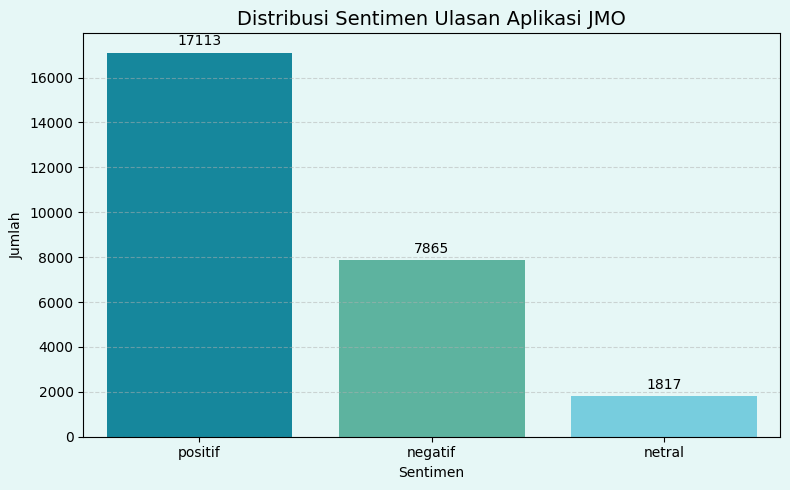

In [ ]:
order = df['sentimen'].value_counts().index
warna_background = '#E6F7F6'

plt.figure(figsize=(8, 5), facecolor=warna_background)
ax = sns.countplot(
    data=df,
    x='sentimen',
    order=order,
    palette=['#0097B2', '#4FC1A6', '#66D9EF']
)

# Atur latar belakang area plot
ax.set_facecolor(warna_background)

# Tambahkan label jumlah di atas tiap bar
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Tambahkan detail plot
plt.title('Distribusi Sentimen Ulasan Aplikasi JMO', fontsize=14)
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/tmp/ipython-input-10-3330225399.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


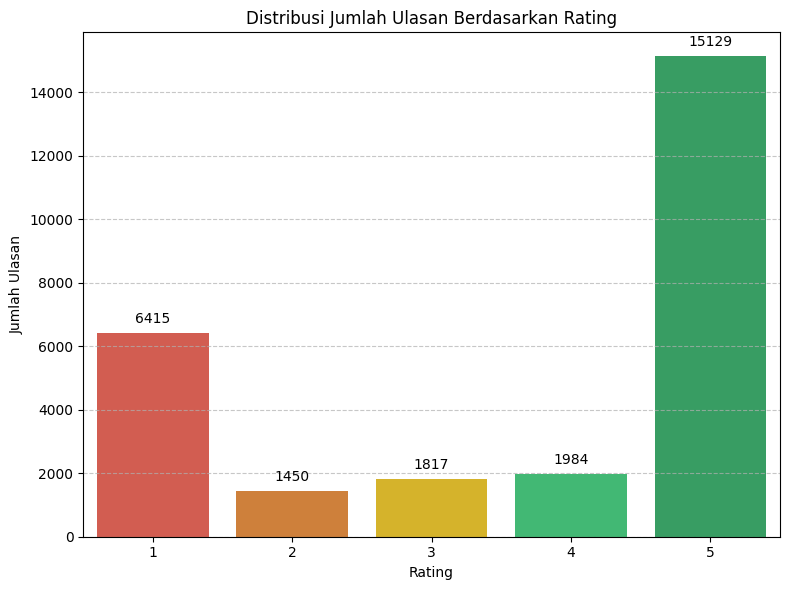

In [ ]:
# Hitung distribusi rating
rating_counts = df['rating'].value_counts().sort_index()

# Buat dataframe dari distribusi
rating_df = pd.DataFrame({'Rating': rating_counts.index, 'Jumlah': rating_counts.values})

# Pewarnaan manual agar konsisten (merah ke hijau)
colors = {
    1: '#E74C3C',  # merah
    2: '#E67E22',  # oranye
    3: '#F1C40F',  # kuning
    4: '#2ECC71',  # hijau muda
    5: '#27AE60'   # hijau tua
}

plt.figure(figsize=(8, 6))
bars = sns.barplot(
    data=rating_df,
    x='Rating',
    y='Jumlah',
    palette=[colors[r] for r in rating_df['Rating']]
)

# Tambahkan label di atas setiap bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{int(height)}',
                  xy=(bar.get_x() + bar.get_width() / 2, height),
                  xytext=(0, 5),
                  textcoords='offset points',
                  ha='center', va='bottom',
                  fontsize=10)

plt.title('Distribusi Jumlah Ulasan Berdasarkan Rating')
plt.xlabel('Rating')
plt.ylabel('Jumlah Ulasan')
plt.xticks([0, 1, 2, 3, 4], ['1', '2', '3', '4', '5'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## WordCloud Awal - Berdasarkan Label Asli

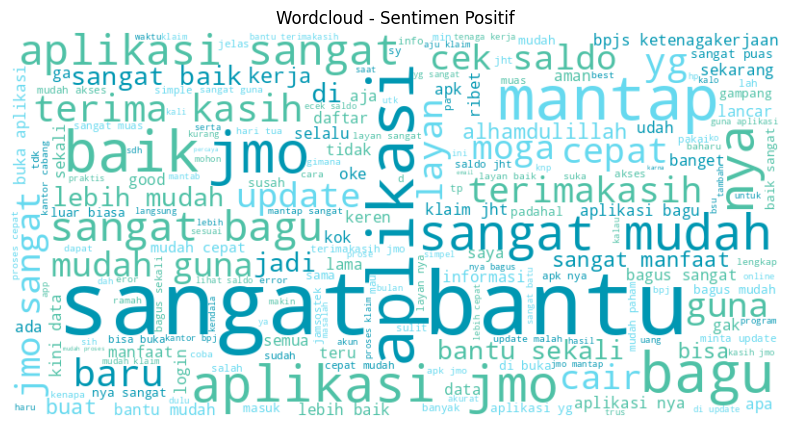

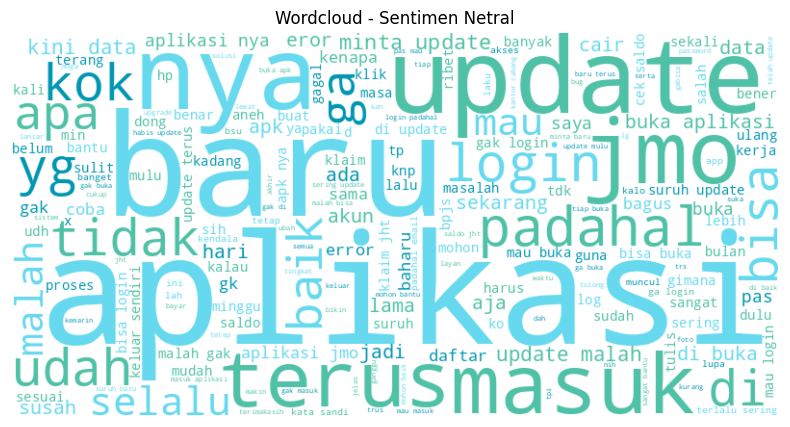

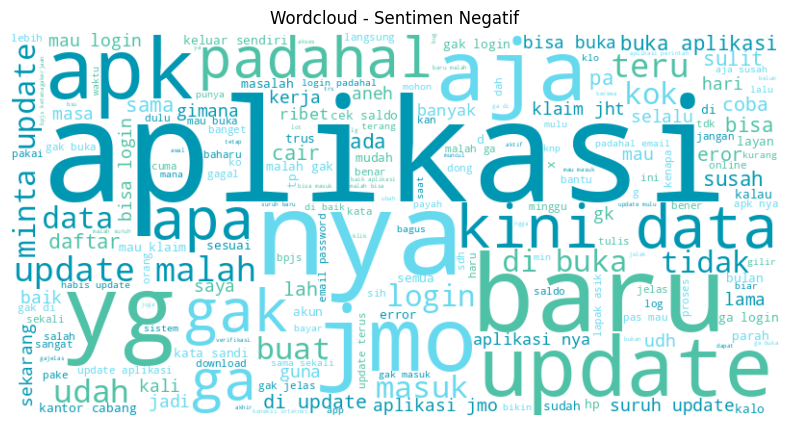

In [ ]:
class JMOColorFunc:
    def __init__(self):
        self.colors = ['#0097B2', '#4FC1A6', '#66D9EF']
    def __call__(self, *args, **kwargs):
        import random
        return random.choice(self.colors)

for s in ['positif', 'netral', 'negatif']:
    text = ' '.join(df[df['sentimen'] == s]['clean_review'])
    wc = WordCloud(width=800, height=400, background_color='white', color_func=JMOColorFunc()).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Wordcloud - Sentimen {s.capitalize()}')
    plt.show()

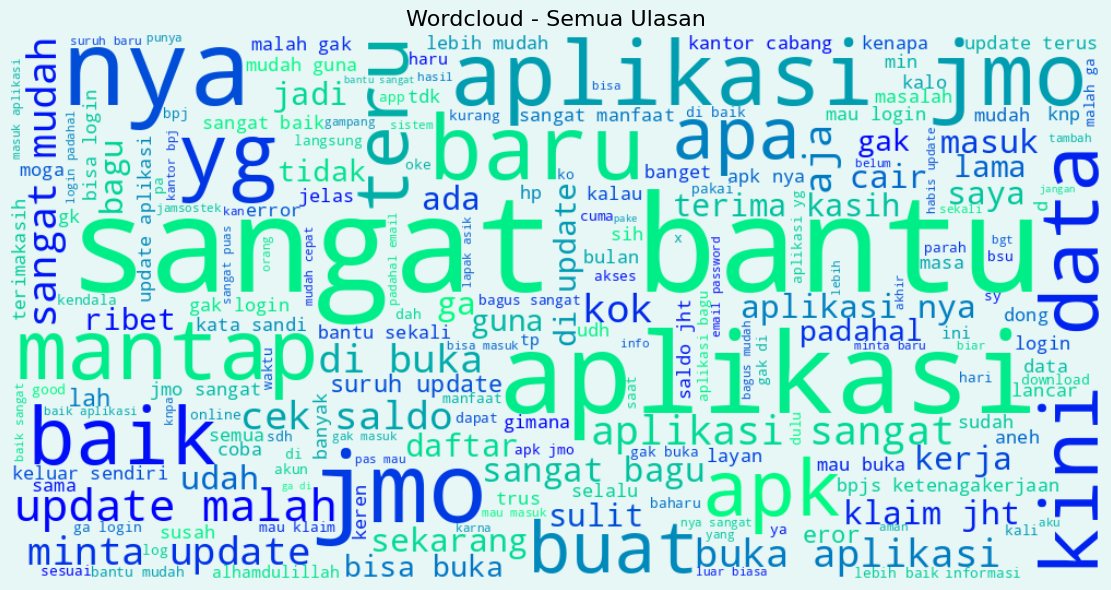

In [ ]:
# Gabungkan semua review jadi satu string (pastikan 'df' dan kolom 'clean_review' ada)
text_all = ' '.join(df['clean_review'].astype(str))

# Buat WordCloud
wc_all = WordCloud(
    width=1000,
    height=500,
    background_color='#E6F7F6',  # hijau kebiruan terang
    colormap='winter',           # gradasi biru-ke-hijau
    font_path=None               # tambahkan jika kamu pakai font custom
).generate(text_all)

# Tampilkan
plt.figure(figsize=(12, 6), facecolor='#E6F7F6')
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud - Semua Ulasan', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Pisahkan jadi kata-kata
words = text_all.split()

# Hitung frekuensi tiap kata
word_freq = Counter(words)

# Ubah ke DataFrame biar rapi
df_word_freq = pd.DataFrame(word_freq.items(), columns=['Kata', 'Frekuensi'])

# Urutkan dari frekuensi tertinggi
df_word_freq = df_word_freq.sort_values(by='Frekuensi', ascending=False).reset_index(drop=True)

# Tampilkan 20 kata paling sering muncul
print(df_word_freq.head(20))

        Kata  Frekuensi
0   aplikasi       6722
1     sangat       5011
2     update       4055
3        jmo       3340
4      mudah       3336
5      bantu       3138
6        nya       3000
7       buka       2797
8      login       2527
9       baik       2402
10        di       2362
11     bagus       2312
12      baru       2223
13       mau       2158
14       gak       2086
15     malah       1973
16      bisa       1880
17        ga       1663
18     terus       1616
19     masuk       1566


## Representasi Teks (TF-IDF dan BoW)

In [ ]:
X = df['clean_review']
y = df['sentimen']

tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=5000)
bow = CountVectorizer(ngram_range=(1,2), max_features=5000)

X_tfidf = tfidf.fit_transform(X)
X_bow = bow.fit_transform(X)

ros = RandomOverSampler(random_state=42)
X_tfidf_res, y_res = ros.fit_resample(X_tfidf, y)
X_bow_res, _ = ros.fit_resample(X_bow, y)

Xtf_train, Xtf_test, ytf_train, ytf_test = train_test_split(X_tfidf_res, y_res, test_size=0.2, random_state=42)
Xbow_train, Xbow_test, ybow_train, ybow_test = train_test_split(X_bow_res, y_res, test_size=0.2, random_state=42)


## Modeling & Evaluasi Awal (Tanpa Tuning)

In [ ]:
# === Inisialisasi model dasar ===
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier()
}

tfidf_results = []
bow_results = []

# === Model Default (Tanpa Tuning) ===
for name, model in models.items():
    # TF-IDF
    model.fit(Xtf_train, ytf_train)
    pred_tf = model.predict(Xtf_test)
    tfidf_results.append({
        'Model': f'{name} (TF-IDF)',
        'Accuracy': accuracy_score(ytf_test, pred_tf),
        'Precision': precision_score(ytf_test, pred_tf, average='weighted'),
        'Recall': recall_score(ytf_test, pred_tf, average='weighted'),
        'F1 Score': f1_score(ytf_test, pred_tf, average='weighted')
    })
    print(f"\n=== {name} (TF-IDF) ===")
    print(classification_report(ytf_test, pred_tf))

    # BoW
    model.fit(Xbow_train, ybow_train)
    pred_bow = model.predict(Xbow_test)
    bow_results.append({
        'Model': f'{name} (BoW)',
        'Accuracy': accuracy_score(ybow_test, pred_bow),
        'Precision': precision_score(ybow_test, pred_bow, average='weighted'),
        'Recall': recall_score(ybow_test, pred_bow, average='weighted'),
        'F1 Score': f1_score(ybow_test, pred_bow, average='weighted')
    })
    print(f"\n=== {name} (BoW) ===")
    print(classification_report(ybow_test, pred_bow))


=== Naive Bayes (TF-IDF) ===
              precision    recall  f1-score   support

     negatif       0.75      0.71      0.73      3518
      netral       0.65      0.75      0.70      3361
     positif       0.84      0.76      0.80      3389

    accuracy                           0.74     10268
   macro avg       0.75      0.74      0.74     10268
weighted avg       0.75      0.74      0.74     10268


=== Naive Bayes (BoW) ===
              precision    recall  f1-score   support

     negatif       0.75      0.67      0.71      3518
      netral       0.62      0.73      0.67      3361
     positif       0.81      0.76      0.79      3389

    accuracy                           0.72     10268
   macro avg       0.73      0.72      0.72     10268
weighted avg       0.73      0.72      0.72     10268


=== Logistic Regression (TF-IDF) ===
              precision    recall  f1-score   support

     negatif       0.79      0.77      0.78      3518
      netral       0.75      0.81 

## Hyperparameter Tuning

### Naive Bayes

In [ ]:
# 1. Naive Bayes (TF-IDF)
param_nb = {'alpha': [0.1, 0.5, 1.0, 2.0]}
grid_nb_tf = GridSearchCV(MultinomialNB(), param_grid=param_nb, cv=3, scoring='accuracy')
grid_nb_tf.fit(Xtf_train, ytf_train)
best_nb_tf = grid_nb_tf.best_estimator_
pred_nb_tf = best_nb_tf.predict(Xtf_test)
tfidf_results.append({
    'Model': 'Tuned Naive Bayes (TF-IDF)',
    'Accuracy': accuracy_score(ytf_test, pred_nb_tf),
    'Precision': precision_score(ytf_test, pred_nb_tf, average='weighted'),
    'Recall': recall_score(ytf_test, pred_nb_tf, average='weighted'),
    'F1 Score': f1_score(ytf_test, pred_nb_tf, average='weighted')
})

# Naive Bayes (BoW)
grid_nb_bow = GridSearchCV(MultinomialNB(), param_grid=param_nb, cv=3, scoring='accuracy')
grid_nb_bow.fit(Xbow_train, ybow_train)
best_nb_bow = grid_nb_bow.best_estimator_
pred_nb_bow = best_nb_bow.predict(Xbow_test)
bow_results.append({
    'Model': 'Tuned Naive Bayes (BoW)',
    'Accuracy': accuracy_score(ybow_test, pred_nb_bow),
    'Precision': precision_score(ybow_test, pred_nb_bow, average='weighted'),
    'Recall': recall_score(ybow_test, pred_nb_bow, average='weighted'),
    'F1 Score': f1_score(ybow_test, pred_nb_bow, average='weighted')
})

### Random Forest

In [ ]:
# Random Forest (TF-IDF)
param_rf = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
grid_rf = GridSearchCV(RandomForestClassifier(), param_grid=param_rf, cv=3, scoring='accuracy')
grid_rf.fit(Xtf_train, ytf_train)
best_rf = grid_rf.best_estimator_
pred_rf = best_rf.predict(Xtf_test)
tfidf_results.append({
    'Model': 'Tuned Random Forest (TF-IDF)',
    'Accuracy': accuracy_score(ytf_test, pred_rf),
    'Precision': precision_score(ytf_test, pred_rf, average='weighted'),
    'Recall': recall_score(ytf_test, pred_rf, average='weighted'),
    'F1 Score': f1_score(ytf_test, pred_rf, average='weighted')
})

# Random Forest (BoW)
grid_rf_bow = GridSearchCV(RandomForestClassifier(), param_grid=param_rf, cv=3, scoring='accuracy')
grid_rf_bow.fit(Xbow_train, ybow_train)
best_rf_bow = grid_rf_bow.best_estimator_
pred_rf_bow = best_rf_bow.predict(Xbow_test)
bow_results.append({
    'Model': 'Tuned Random Forest (BoW)',
    'Accuracy': accuracy_score(ybow_test, pred_rf_bow),
    'Precision': precision_score(ybow_test, pred_rf_bow, average='weighted'),
    'Recall': recall_score(ybow_test, pred_rf_bow, average='weighted'),
    'F1 Score': f1_score(ybow_test, pred_rf_bow, average='weighted')
})

### Logistic Regression

In [ ]:
# Logistic Regression Tuned (TF-IDF)
param_logreg_tf = {'C': [0.1, 1, 10]}
grid_logreg_tf = GridSearchCV(LogisticRegression(max_iter=1000), param_grid=param_logreg_tf, cv=3, scoring='accuracy')
grid_logreg_tf.fit(Xtf_train, ytf_train)
best_logreg_tf = grid_logreg_tf.best_estimator_

pred_logreg_tf = best_logreg_tf.predict(Xtf_test)
tfidf_results.append({
    'Model': 'Tuned Logistic Regression (TF-IDF)',
    'Accuracy': accuracy_score(ytf_test, pred_logreg_tf),
    'Precision': precision_score(ytf_test, pred_logreg_tf, average='weighted'),
    'Recall': recall_score(ytf_test, pred_logreg_tf, average='weighted'),
    'F1 Score': f1_score(ytf_test, pred_logreg_tf, average='weighted')
})

# Logistic Regression (BoW)
param_logreg = {'C': [0.1, 1, 10]}
grid_logreg = GridSearchCV(LogisticRegression(max_iter=1000), param_grid=param_logreg, cv=3, scoring='accuracy')
grid_logreg.fit(Xbow_train, ybow_train)
best_logreg = grid_logreg.best_estimator_
pred_logreg = best_logreg.predict(Xbow_test)
bow_results.append({
    'Model': 'Tuned Logistic Regression (BoW)',
    'Accuracy': accuracy_score(ybow_test, pred_logreg),
    'Precision': precision_score(ybow_test, pred_logreg, average='weighted'),
    'Recall': recall_score(ybow_test, pred_logreg, average='weighted'),
    'F1 Score': f1_score(ybow_test, pred_logreg, average='weighted')
})

## EVALUASI DEFAULT DAN TUNED

In [ ]:
df_tfidf = pd.DataFrame(tfidf_results).sort_values(by='Accuracy', ascending=False).round(4)
df_bow = pd.DataFrame(bow_results).sort_values(by='Accuracy', ascending=False).round(4)

print("\nModels with TF-IDF Results")
print(df_tfidf.to_string(index=False))

print("\nModels with Bag of Words Results")
print(df_bow.to_string(index=False))


Models with TF-IDF Results
                             Model  Accuracy  Precision  Recall  F1 Score
            Random Forest (TF-IDF)    0.9191     0.9215  0.9191    0.9185
      Tuned Random Forest (TF-IDF)    0.9180     0.9206  0.9180    0.9174
Tuned Logistic Regression (TF-IDF)    0.8328     0.8351  0.8328    0.8326
      Logistic Regression (TF-IDF)    0.8000     0.8025  0.8000    0.8006
        Tuned Naive Bayes (TF-IDF)    0.7517     0.7581  0.7517    0.7532
              Naive Bayes (TF-IDF)    0.7410     0.7495  0.7410    0.7430

Models with Bag of Words Results
                          Model  Accuracy  Precision  Recall  F1 Score
            Random Forest (BoW)    0.9145     0.9161  0.9145    0.9136
      Tuned Random Forest (BoW)    0.9141     0.9161  0.9141    0.9132
Tuned Logistic Regression (BoW)    0.8452     0.8460  0.8452    0.8447
      Logistic Regression (BoW)    0.8263     0.8272  0.8263    0.8261
        Tuned Naive Bayes (BoW)    0.7302     0.7362  0.7302    0

## Grafik Perbandingan Akurasi

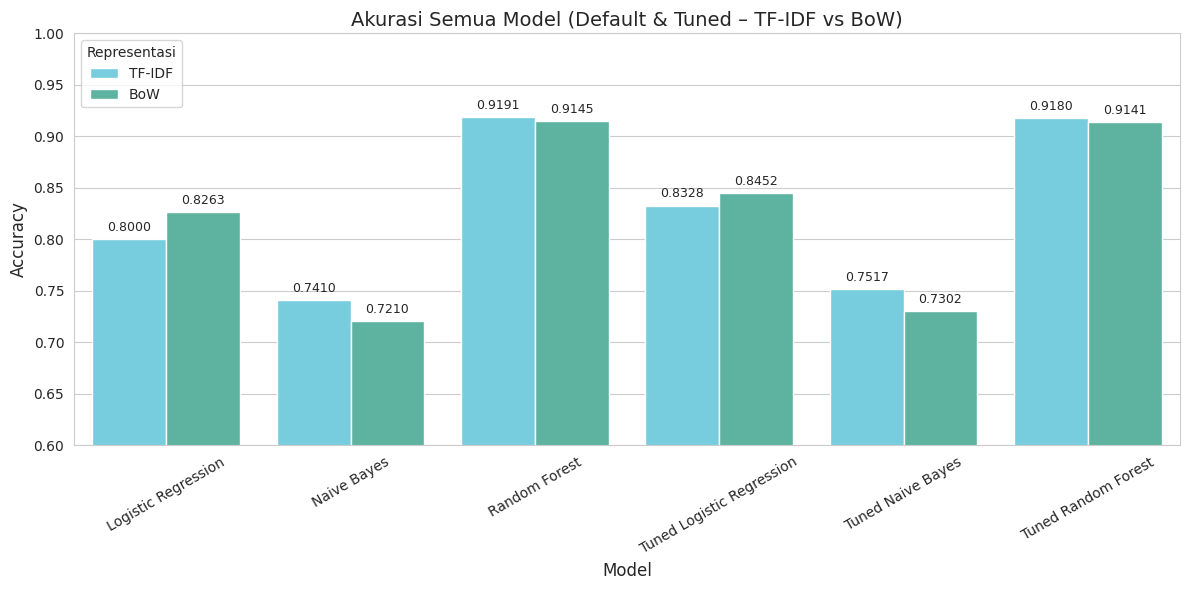

In [ ]:
df_all_tfidf = pd.DataFrame(tfidf_results)
df_all_tfidf['Representasi'] = 'TF-IDF'
df_all_tfidf['Model'] = df_all_tfidf['Model'].str.replace(' \(TF-IDF\)', '', regex=True)

df_all_bow = pd.DataFrame(bow_results)
df_all_bow['Representasi'] = 'BoW'
df_all_bow['Model'] = df_all_bow['Model'].str.replace(' \(BoW\)', '', regex=True)

# Gabungkan dan atur urutan model
df_plot = pd.concat([
    df_all_tfidf[['Model', 'Representasi', 'Accuracy']],
    df_all_bow[['Model', 'Representasi', 'Accuracy']]
], ignore_index=True)

model_order = sorted(df_plot['Model'].unique())
df_plot['Model'] = pd.Categorical(df_plot['Model'], categories=model_order, ordered=True)

# Plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
colors = ['#66D9EF', '#4FC1A6']
bar = sns.barplot(
    data=df_plot,
    x='Model',
    y='Accuracy',
    hue='Representasi',
    palette=colors
)

for p in bar.patches:
    height = p.get_height()
    bar.annotate(f'{height:.4f}',
                 (p.get_x() + p.get_width() / 2, height + 0.005),
                 ha='center', va='bottom', fontsize=9)

plt.title('Akurasi Semua Model (Default & Tuned – TF-IDF vs BoW)', fontsize=14)
plt.ylim(0.6, 1.0)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=30)
plt.legend(title='Representasi')
plt.tight_layout()
plt.show()

## Confusion Matrix

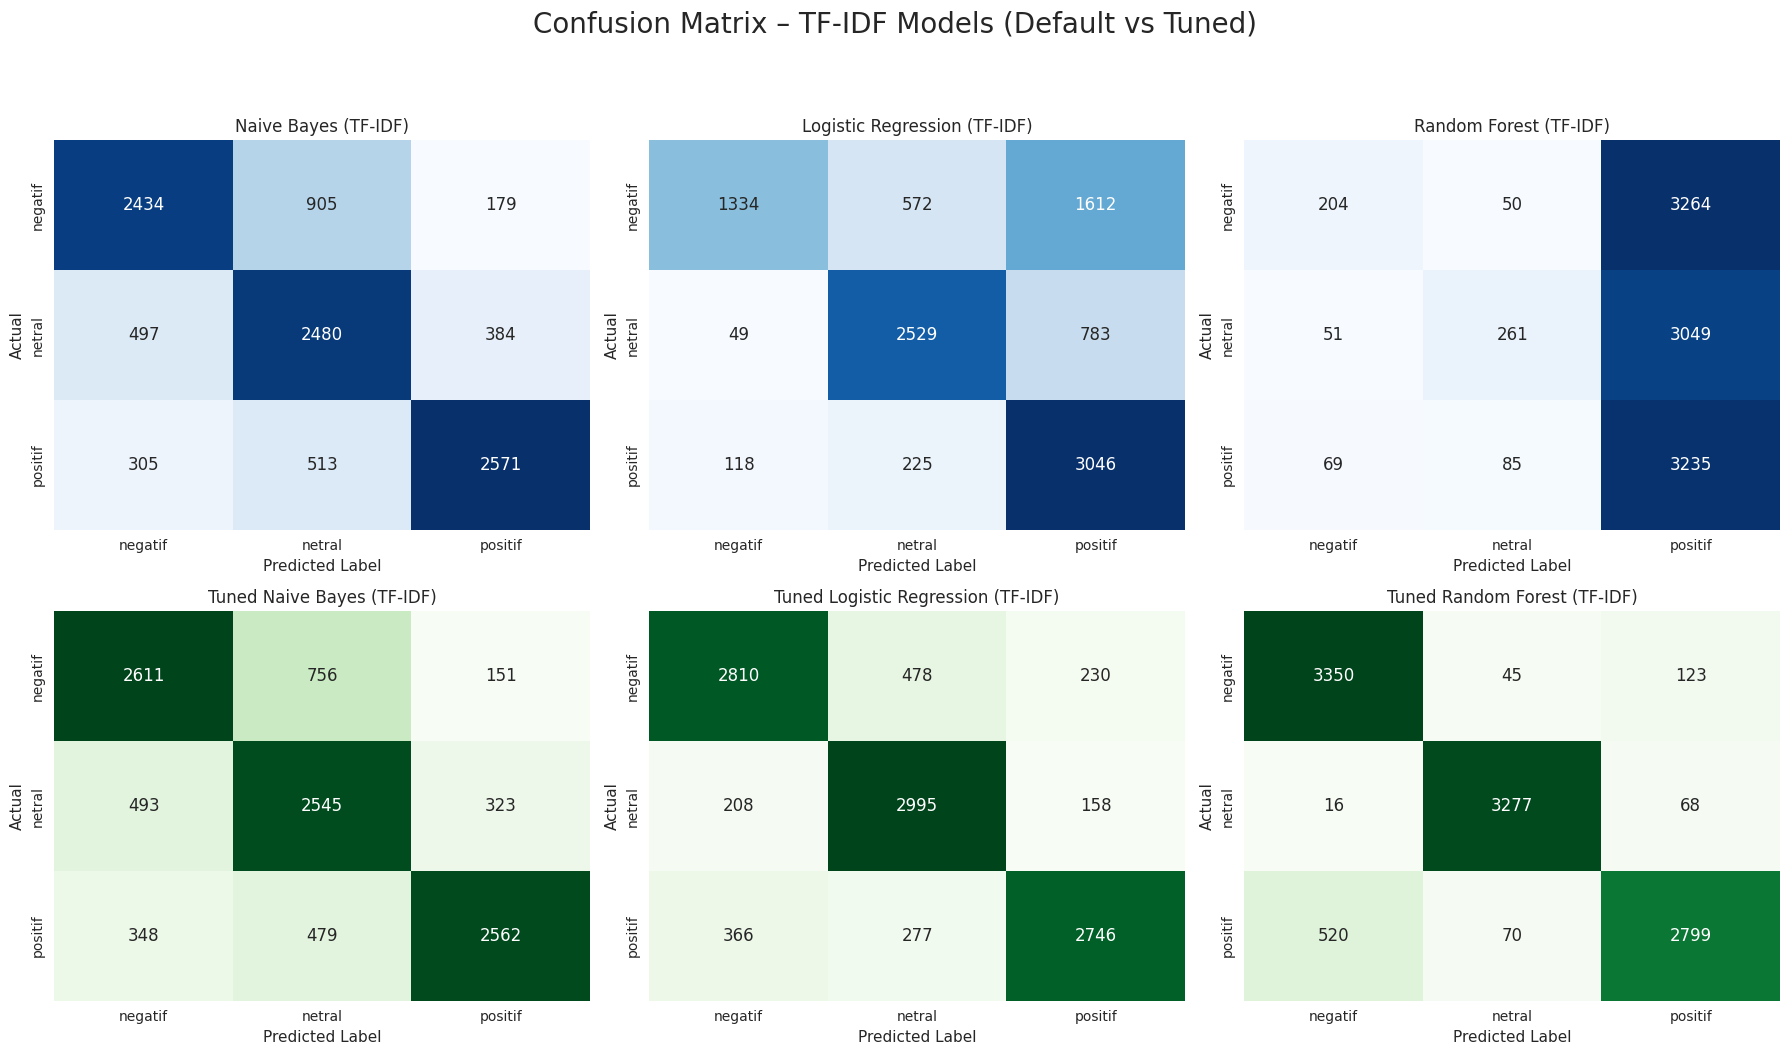

In [ ]:
# Label 3 kelas
labels = ['negatif', 'netral', 'positif']
le = LabelEncoder()
le.fit(labels)

# Daftar model dan prediksi (TF-IDF only)
model_preds = [
    ('Naive Bayes (TF-IDF)', models['Naive Bayes'].predict(Xtf_test), ytf_test, 'default'),
    ('Logistic Regression (TF-IDF)', models['Logistic Regression'].predict(Xtf_test), ytf_test, 'default'),
    ('Random Forest (TF-IDF)', models['Random Forest'].predict(Xtf_test), ytf_test, 'default'),
    ('Tuned Naive Bayes (TF-IDF)', best_nb_tf.predict(Xtf_test), ytf_test, 'tuned'),
    ('Tuned Logistic Regression (TF-IDF)', best_logreg_tf.predict(Xtf_test), ytf_test, 'tuned'),
    ('Tuned Random Forest (TF-IDF)', best_rf.predict(Xtf_test), ytf_test, 'tuned'),
]

# Grid 2 baris × 3 kolom
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Confusion Matrix – TF-IDF Models (Default vs Tuned)', fontsize=20, y=1.05)

for ax, (title, y_pred, y_true, tipe) in zip(axes.flat, model_preds):
    cm = confusion_matrix(le.transform(y_true), le.transform(y_pred), labels=[0, 1, 2])

    cmap_used = 'Blues' if tipe == 'default' else 'Greens'  # Bedakan default dan tuned

    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_used,
                xticklabels=labels, yticklabels=labels, ax=ax, cbar=False,
                annot_kws={"size": 12})
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.show()

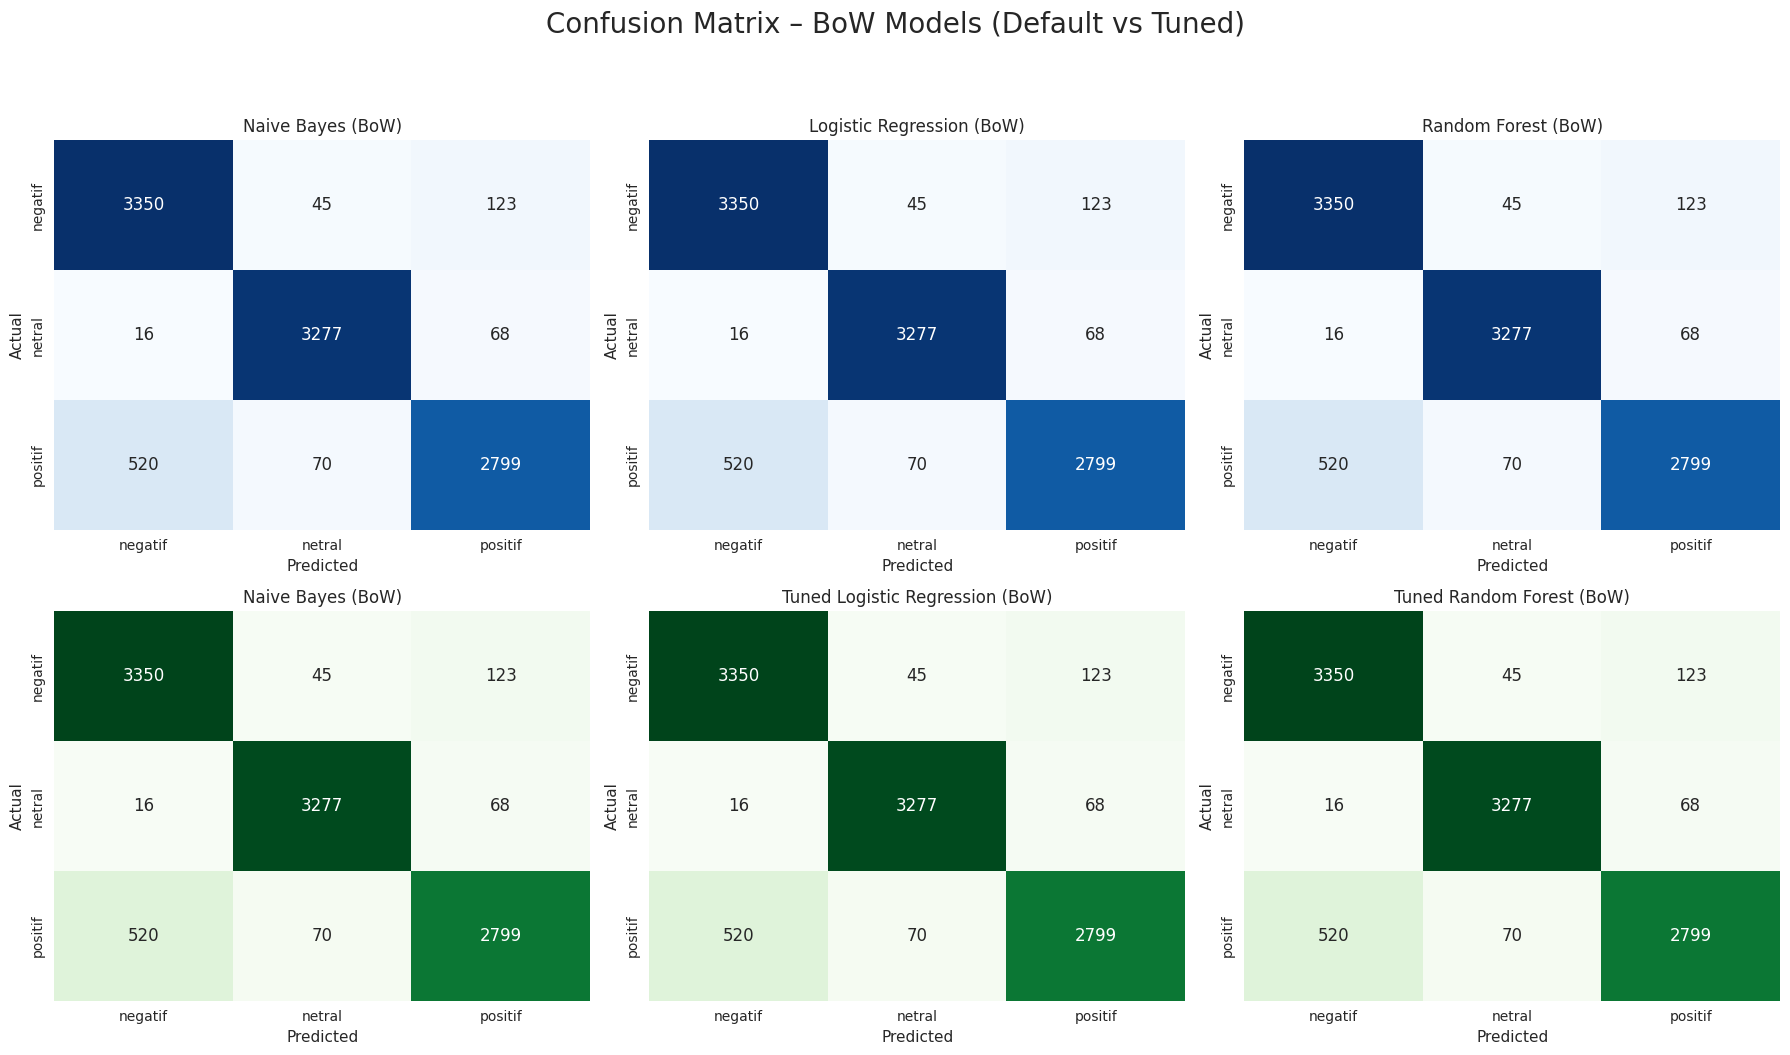

In [ ]:
# Label 3 kelas
labels = ['negatif', 'netral', 'positif']
le = LabelEncoder()
le.fit(labels)

# Daftar model dan prediksi (BoW only)
model_preds1 = [
    ('Naive Bayes (BoW)', models['Naive Bayes'].predict(Xbow_test), ybow_test, 'default'),
    ('Logistic Regression (BoW)', models['Logistic Regression'].predict(Xbow_test), ybow_test, 'default'),
    ('Random Forest (BoW)', models['Random Forest'].predict(Xbow_test), ybow_test, 'default'),
    ('Naive Bayes (BoW)', best_nb_bow.predict(Xbow_test), ybow_test, 'tuned'),
    ('Tuned Logistic Regression (BoW)', best_logreg.predict(Xbow_test), ybow_test, 'tuned'),
    ('Tuned Random Forest (BoW)', best_rf_bow.predict(Xbow_test), ybow_test, 'tuned'),
]

# Grid 2 baris × 3 kolom
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Confusion Matrix – BoW Models (Default vs Tuned)', fontsize=20, y=1.05)

for ax, (title, y_pred, y_true, tipe) in zip(axes.flat, model_preds1):
    cm1 = confusion_matrix(le.transform(y_true), le.transform(y_pred), labels=[0, 1, 2])

    cmap_used = 'Blues' if tipe == 'default' else 'Greens'  # Bedakan default dan tuned

    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_used,
                xticklabels=labels, yticklabels=labels, ax=ax, cbar=False,
                annot_kws={"size": 12})
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.show()